# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [1]:
# # Instalação base do projeto + PyTorch com CUDA (Windows / pip)

# %pip install -q --upgrade pip

# # Dependências gerais
# %pip install -q \
#     numpy \
#     pandas \
#     matplotlib \
#     pillow \
#     tqdm \
#     scipy \
#     scikit-learn \
#     jupyter \
#     ipykernel \
#     datasets \
#     accelerate \
#     diffusers \
#     transformers \
#     clean-fid \
#     torchmetrics


#%pip install -q torch-fidelity

# # PyTorch com CUDA (instalar em separado)
# %pip uninstall -y torch torchvision torchaudio
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [2]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [3]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    print("GPU não disponível para o PyTorch neste ambiente.")

torch version: 2.11.0+cu126
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 3080 Ti


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
KAGGLE_ROOT = PROJECT_ROOT / "ArtBench-10"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("KAGGLE_ROOT  =", KAGGLE_ROOT)
print("SCRIPTS_DIR  =", SCRIPTS_DIR)

PROJECT_ROOT = c:\git\GAI-Project1
KAGGLE_ROOT  = c:\git\GAI-Project1\ArtBench-10
SCRIPTS_DIR  = c:\git\GAI-Project1\scripts


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='c:\git\GAI-Project1\ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [8]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

In [9]:
def denorm(x):
    return x.clamp(-1, 1).add(1).div(2)

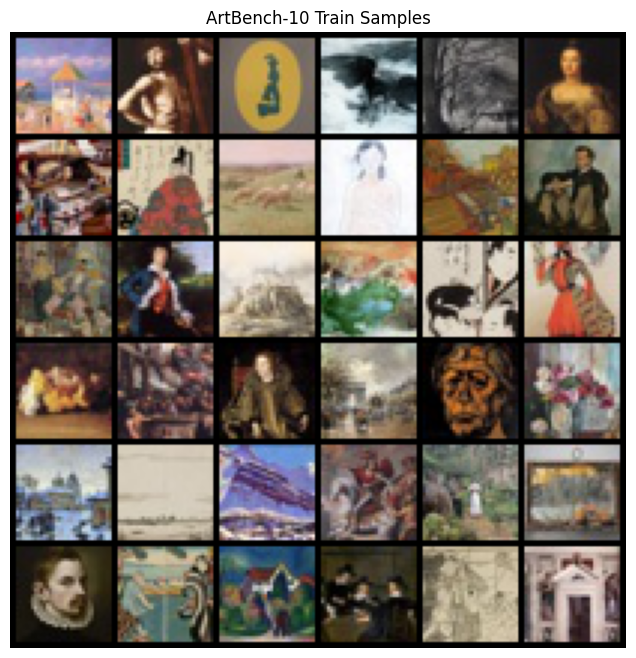

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [10]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(denorm(x), nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np.clip(np_img, 0, 1))
    plt.axis('off')
    plt.title(title)
    plt.show()

    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [11]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(denorm(x[i]), path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data\train_subset\images
Metadata CSV: exported_data\train_subset\metadata.csv


# Common Utilities

In [12]:
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def show_image_grid(images, title="Images", nrow=8, figsize=(8, 8), normalize=False):
    images = images.detach().cpu()

    if normalize:
        images = denorm(images)

    grid = make_grid(images, nrow=nrow, padding=2)
    grid = grid.permute(1, 2, 0)

    plt.figure(figsize=figsize)
    plt.imshow(grid)
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(8, 4))
    for key, values in history.items():
        plt.plot(values, label=key)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def save_checkpoint(model, optimizer, epoch, path, history=None, extra=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "history": history,
        "extra": extra,
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_checkpoint(model, optimizer, path, map_location="cpu"):
    checkpoint = torch.load(path, map_location=map_location)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint["optimizer_state_dict"] is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    print(f"Checkpoint loaded from: {path}")
    return checkpoint

# ConvVAE

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: [B, 3, 32, 32] -> [B, 256, 4, 4]
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # -> 16x16
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # -> 8x8
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # -> 4x4
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # -> 4x4
            nn.ReLU(inplace=True),
        )

        self.flatten_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Decoder: [B, latent_dim] -> [B, 3, 32, 32]
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1), # -> 4x4
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> 8x8
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> 16x16
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> 32x32
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), 256, 4, 4)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

### VAE Utilities

In [14]:
@torch.no_grad()
def show_vae_reconstructions(model, dataloader, device, num_images=16):
    """
    Show original images and their reconstructions side by side.
    """
    model.eval()

    batch = next(iter(dataloader))
    x, y, real_idx = batch
    x = x.to(device)

    x_hat, mu, logvar = model(x)

    x = x[:num_images].cpu()
    x_hat = x_hat[:num_images].cpu()

    print("Original images")
    show_image_grid(x, title="Original Images", nrow=4, figsize=(8, 8), normalize=True)

    print("Reconstructed images")
    show_image_grid(x_hat, title="Reconstructed Images", nrow=4, figsize=(8, 8), normalize=True)


@torch.no_grad()
def sample_vae(model, device, num_samples=16):
    """
    Sample new images from the VAE latent space.
    """
    model.eval()

    z = torch.randn(num_samples, model.latent_dim, device=device)
    samples = model.decode(z).cpu()

    show_image_grid(samples, title="VAE Samples", nrow=4, figsize=(8, 8), normalize=True)
    return samples


@torch.no_grad()
def interpolate_vae(model, dataloader, device, num_steps=8):
    """
    Interpolate between two images in latent space and decode the intermediate points.
    """
    model.eval()

    batch = next(iter(dataloader))
    x, y, real_idx = batch
    x = x.to(device)

    x1 = x[0:1]
    x2 = x[1:2]

    mu1, logvar1 = model.encode(x1)
    mu2, logvar2 = model.encode(x2)

    z1 = model.reparameterise(mu1, logvar1)
    z2 = model.reparameterise(mu2, logvar2)

    alphas = torch.linspace(0.0, 1.0, steps=num_steps, device=device)

    z_interp = []
    for alpha in alphas:
        z = (1 - alpha) * z1 + alpha * z2
        z_interp.append(z)

    z_interp = torch.cat(z_interp, dim=0)
    x_interp = model.decode(z_interp).cpu()

    show_image_grid(
        x_interp,
        title="VAE Latent Interpolation",
        nrow=num_steps,
        figsize=(2 * num_steps, 2),
        normalize=True,
    )
    return x_interp

### VAE Training Utilities

In [15]:
import torch.optim as optim
from tqdm.auto import tqdm


def train_one_epoch_vae(model, dataloader, optimizer, device, beta=1.0):
    """
    Train the VAE for one epoch.
    """
    model.train()

    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    n_samples = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for x, y, real_idx in progress_bar:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(x_hat, x, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        n_samples += batch_size

        running_loss += loss.item() * batch_size
        running_recon += recon_loss.item() * batch_size
        running_kl += kl_loss.item() * batch_size

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "recon": f"{recon_loss.item():.4f}",
            "kl": f"{kl_loss.item():.4f}",
        })

    epoch_loss = running_loss / n_samples
    epoch_recon = running_recon / n_samples
    epoch_kl = running_kl / n_samples

    return epoch_loss, epoch_recon, epoch_kl

### VAE Experiment Configurations

In [16]:
vae_configs = [
    {"latent_dim": 32,  "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 64,  "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 256, "beta": 0.5, "learning_rate": 1e-3},

    {"latent_dim": 64,  "beta": 1.0, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 1.0, "learning_rate": 1e-3},

    {"latent_dim": 64,  "beta": 2.0, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 2.0, "learning_rate": 1e-3},

    {"latent_dim": 64,  "beta": 0.5, "learning_rate": 5e-4},
    {"latent_dim": 128, "beta": 0.5, "learning_rate": 5e-4},

    {"latent_dim": 64,  "beta": 1.0, "learning_rate": 5e-4},
    {"latent_dim": 128, "beta": 1.0, "learning_rate": 5e-4},
]

vae_num_epochs_search = 20

print(f"Number of VAE configurations: {len(vae_configs)}")
for i, config in enumerate(vae_configs, start=1):
    print(f"{i:2d}. {config}")

Number of VAE configurations: 12
 1. {'latent_dim': 32, 'beta': 0.5, 'learning_rate': 0.001}
 2. {'latent_dim': 64, 'beta': 0.5, 'learning_rate': 0.001}
 3. {'latent_dim': 128, 'beta': 0.5, 'learning_rate': 0.001}
 4. {'latent_dim': 256, 'beta': 0.5, 'learning_rate': 0.001}
 5. {'latent_dim': 64, 'beta': 1.0, 'learning_rate': 0.001}
 6. {'latent_dim': 128, 'beta': 1.0, 'learning_rate': 0.001}
 7. {'latent_dim': 64, 'beta': 2.0, 'learning_rate': 0.001}
 8. {'latent_dim': 128, 'beta': 2.0, 'learning_rate': 0.001}
 9. {'latent_dim': 64, 'beta': 0.5, 'learning_rate': 0.0005}
10. {'latent_dim': 128, 'beta': 0.5, 'learning_rate': 0.0005}
11. {'latent_dim': 64, 'beta': 1.0, 'learning_rate': 0.0005}
12. {'latent_dim': 128, 'beta': 1.0, 'learning_rate': 0.0005}


## VAE Experiment Runner

In [17]:
def run_vae_experiment(config, train_loader, device, num_epochs=10, seed=42):
    """
    Train one VAE configuration and return:
    - the trained model
    - the training history
    - a result summary dictionary
    """
    set_seed(seed)

    latent_dim = config["latent_dim"]
    beta = config["beta"]
    learning_rate = config["learning_rate"]

    model = ConvVAE(latent_dim=latent_dim).to(device)
    optimiser = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
    }

    print("-" * 70)
    print(
        f"Training VAE | latent_dim={latent_dim} | "
        f"beta={beta} | learning_rate={learning_rate}"
    )
    print(f"Trainable parameters: {count_parameters(model):,}")

    for epoch in range(num_epochs):
        train_loss, train_recon, train_kl = train_one_epoch_vae(
            model=model,
            dataloader=train_loader,
            optimizer=optimiser,
            device=device,
            beta=beta,
        )

        history["train_loss"].append(train_loss)
        history["train_recon"].append(train_recon)
        history["train_kl"].append(train_kl)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"loss={train_loss:.4f} "
            f"recon={train_recon:.4f} "
            f"kl={train_kl:.4f}"
        )

    result = {
        "latent_dim": latent_dim,
        "beta": beta,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "final_train_loss": history["train_loss"][-1],
        "final_train_recon": history["train_recon"][-1],
        "final_train_kl": history["train_kl"][-1],
    }

    return model, history, result

## Run VAE Experiments

In [18]:
device = get_device()
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti


In [19]:
vae_models = []
vae_histories = []
vae_results = []

for run_idx, config in enumerate(vae_configs, start=1):
    print(f"\nStarting VAE experiment {run_idx}/{len(vae_configs)}")

    model, history, result = run_vae_experiment(
        config=config,
        train_loader=train_loader_from_csv,
        device=device,
        num_epochs=vae_num_epochs_search,
        seed=SEED,
    )

    result["run_idx"] = run_idx

    vae_models.append(model)
    vae_histories.append(history)
    vae_results.append(result)


Starting VAE experiment 1/12
----------------------------------------------------------------------
Training VAE | latent_dim=32 | beta=0.5 | learning_rate=0.001
Trainable parameters: 1,318,659


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/20] loss=404.6563 recon=391.2155 kl=26.8816


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [2/20] loss=261.1647 recon=243.5965 kl=35.1366


...

Epoch [18/20] loss=192.9804 recon=151.8811 kl=41.0992


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [19/20] loss=191.6933 recon=150.2818 kl=41.4115


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [20/20] loss=191.5480 recon=149.8934 kl=41.6546


## VAE Results Table

In [20]:
import pandas as pd

vae_results_df = pd.DataFrame(vae_results).reset_index(drop=True)
vae_results_df

,latent_dim,beta,learning_rate,num_epochs,final_train_loss,final_train_recon,final_train_kl,run_idx
0,32,0.5,0.0010,20,165.215576,139.542209,51.346733,1
1,64,0.5,0.0010,20,157.832192,125.619514,64.425357,2
2,128,0.5,0.0010,20,158.828989,125.513097,66.631785,3
3,256,0.5,0.0010,20,164.341650,130.993190,66.696919,4
4,64,1.0,0.0010,20,188.122821,144.656243,43.466578,5
5,128,1.0,0.0010,20,192.215204,150.027577,42.187627,6
6,64,2.0,0.0010,20,227.765067,175.455082,26.154993,7
7,128,2.0,0.0010,20,232.016056,180.744417,25.635820,8
8,64,0.5,0.0005,20,156.568511,124.196888,64.743247,9
9,128,0.5,0.0005,20,159.434194,127.082036,64.704318,10


## DCGAN Model

In [21]:
import torch
import torch.nn as nn


def weights_init(module):
    """
    Initialise convolutional and batch normalisation layers
    following the standard DCGAN recipe.
    """
    classname = module.__class__.__name__

    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)

    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0.0)


class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64, channels=3):
        super().__init__()
        self.latent_dim = latent_dim

        self.main = nn.Sequential(
            # Input: [B, latent_dim, 1, 1]
            nn.ConvTranspose2d(latent_dim, ngf * 4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # State: [B, ngf*4, 4, 4]
            nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # State: [B, ngf*2, 8, 8]
            nn.ConvTranspose2d(ngf * 2, ngf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # State: [B, ngf, 16, 16]
            nn.ConvTranspose2d(ngf, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
            # Output: [B, 3, 32, 32]
        )

    def forward(self, z):
        return self.main(z)


class Discriminator(nn.Module):
    def __init__(self, ndf=64, channels=3):
        super().__init__()

        self.main = nn.Sequential(
            # Input: [B, 3, 32, 32]
            nn.Conv2d(channels, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # State: [B, ndf, 16, 16]
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # State: [B, ndf*2, 8, 8]
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # State: [B, ndf*4, 4, 4]
            nn.Conv2d(ndf * 4, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
            # Output: [B, 1, 1, 1]
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)

## DCGAN Utilities

In [22]:
import torch.optim as optim
from tqdm.auto import tqdm


@torch.no_grad()
def sample_dcgan(generator, fixed_noise, title="DCGAN Samples"):
    """
    Generate and display images from a fixed latent batch.
    """
    generator.eval()
    fake_images = generator(fixed_noise).cpu()
    show_image_grid(fake_images, title=title, nrow=4, figsize=(8, 8), normalize=True)
    return fake_images


def train_one_epoch_dcgan(
    generator,
    discriminator,
    dataloader,
    optimiser_g,
    optimiser_d,
    criterion,
    device,
    latent_dim=100,
):
    """
    Train DCGAN for one epoch.
    """
    generator.train()
    discriminator.train()

    running_d_loss = 0.0
    running_g_loss = 0.0
    n_batches = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for x, y, real_idx in progress_bar:
        x = x.to(device)

        batch_size = x.size(0)
        real_targets = torch.ones(batch_size, 1, device=device)
        fake_targets = torch.zeros(batch_size, 1, device=device)

        # ----------------------------------------------------
        # Train discriminator
        # ----------------------------------------------------
        optimiser_d.zero_grad()

        real_output = discriminator(x)
        d_loss_real = criterion(real_output, real_targets)

        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_output, fake_targets)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimiser_d.step()

        # ----------------------------------------------------
        # Train generator
        # ----------------------------------------------------
        optimiser_g.zero_grad()

        fake_output = discriminator(fake_images)
        g_loss = criterion(fake_output, real_targets)

        g_loss.backward()
        optimiser_g.step()

        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()
        n_batches += 1

        progress_bar.set_postfix({
            "d_loss": f"{d_loss.item():.4f}",
            "g_loss": f"{g_loss.item():.4f}",
        })

    epoch_d_loss = running_d_loss / n_batches
    epoch_g_loss = running_g_loss / n_batches

    return epoch_d_loss, epoch_g_loss

## DCGAN Experiment Configurations

In [23]:
dcgan_configs = [
    {"latent_dim": 64,  "learning_rate": 2e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},
    {"latent_dim": 100, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},
    {"latent_dim": 128, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},

    {"latent_dim": 64,  "learning_rate": 2e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},
    {"latent_dim": 100, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},
    {"latent_dim": 128, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},

    {"latent_dim": 100, "learning_rate": 1e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},
    {"latent_dim": 100, "learning_rate": 1e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},
]

dcgan_num_epochs_search = 30

print(f"Number of DCGAN configurations: {len(dcgan_configs)}")
for i, config in enumerate(dcgan_configs, start=1):
    print(f"{i:2d}. {config}")

Number of DCGAN configurations: 8
 1. {'latent_dim': 64, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 2. {'latent_dim': 100, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 3. {'latent_dim': 128, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 4. {'latent_dim': 64, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}
 5. {'latent_dim': 100, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}
 6. {'latent_dim': 128, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}
 7. {'latent_dim': 100, 'learning_rate': 0.0001, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 8. {'latent_dim': 100, 'learning_rate': 0.0001, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}


## DCGAN Experiment Runner

In [24]:
def run_dcgan_experiment(config, train_loader, device, num_epochs=15, seed=42):
    """
    Train one DCGAN configuration and return:
    - generator
    - discriminator
    - training history
    - result summary
    """
    set_seed(seed)

    latent_dim = config["latent_dim"]
    learning_rate = config["learning_rate"]
    beta1 = config["beta1"]
    ngf = config["ngf"]
    ndf = config["ndf"]

    generator = Generator(latent_dim=latent_dim, ngf=ngf, channels=3).to(device)
    discriminator = Discriminator(ndf=ndf, channels=3).to(device)

    generator.apply(weights_init)
    discriminator.apply(weights_init)

    criterion = nn.BCELoss()

    optimiser_g = optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta1, 0.999))
    optimiser_d = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta1, 0.999))

    fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

    history = {
        "d_loss": [],
        "g_loss": [],
    }

    print("-" * 70)
    print(
        f"Training DCGAN | latent_dim={latent_dim} | learning_rate={learning_rate} | "
        f"beta1={beta1} | ngf={ngf} | ndf={ndf}"
    )
    print(f"Generator parameters    : {count_parameters(generator):,}")
    print(f"Discriminator parameters: {count_parameters(discriminator):,}")

    for epoch in range(num_epochs):
        epoch_d_loss, epoch_g_loss = train_one_epoch_dcgan(
            generator=generator,
            discriminator=discriminator,
            dataloader=train_loader,
            optimiser_g=optimiser_g,
            optimiser_d=optimiser_d,
            criterion=criterion,
            device=device,
            latent_dim=latent_dim,
        )

        history["d_loss"].append(epoch_d_loss)
        history["g_loss"].append(epoch_g_loss)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"d_loss={epoch_d_loss:.4f} "
            f"g_loss={epoch_g_loss:.4f}"
        )

    # A rough heuristic only for development-stage ranking
    selection_score = abs(history["d_loss"][-1] - 1.0) + history["g_loss"][-1]

    result = {
        "latent_dim": latent_dim,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "ngf": ngf,
        "ndf": ndf,
        "num_epochs": num_epochs,
        "final_d_loss": history["d_loss"][-1],
        "final_g_loss": history["g_loss"][-1],
        "selection_score": selection_score,
        "fixed_noise": fixed_noise.detach().cpu(),
    }

    return generator, discriminator, history, result

## Run DCGAN Experiments

In [25]:
dcgan_generators = []
dcgan_discriminators = []
dcgan_histories = []
dcgan_results = []

for run_idx, config in enumerate(dcgan_configs, start=1):
    print(f"\nStarting DCGAN experiment {run_idx}/{len(dcgan_configs)}")

    generator, discriminator, history, result = run_dcgan_experiment(
        config=config,
        train_loader=train_loader_from_csv,
        device=device,
        num_epochs=dcgan_num_epochs_search,
        seed=SEED,
    )

    result["run_idx"] = run_idx

    dcgan_generators.append(generator)
    dcgan_discriminators.append(discriminator)
    dcgan_histories.append(history)
    dcgan_results.append(result)


Starting DCGAN experiment 1/8
----------------------------------------------------------------------
Training DCGAN | latent_dim=64 | learning_rate=0.0002 | beta1=0.5 | ngf=32 | ndf=32
Generator parameters    : 296,896
Discriminator parameters: 167,808


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/30] d_loss=0.5005 g_loss=3.1994


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [2/30] d_loss=0.5114 g_loss=3.3983


...

Epoch [28/30] d_loss=0.4523 g_loss=3.1515


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [29/30] d_loss=0.4543 g_loss=3.0899


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [30/30] d_loss=0.4351 g_loss=3.0956


## DCGAN Results Table

In [26]:
dcgan_results_df = pd.DataFrame(dcgan_results).reset_index(drop=True)
dcgan_results_df.drop(columns=["fixed_noise"])

,latent_dim,learning_rate,beta1,ngf,ndf,num_epochs,final_d_loss,final_g_loss,selection_score,run_idx
0,64,0.0002,0.5,32,32,30,0.761272,2.054052,2.292780,1
1,100,0.0002,0.5,32,32,30,0.662886,2.596788,2.933902,2
2,128,0.0002,0.5,32,32,30,0.606167,2.428508,2.822341,3
3,64,0.0002,0.5,64,64,30,0.596410,2.981230,3.384821,4
4,100,0.0002,0.5,64,64,30,0.406832,2.963294,3.556462,5
5,128,0.0002,0.5,64,64,30,0.664082,2.829075,3.164993,6
6,100,0.0001,0.5,32,32,30,0.607207,2.763534,3.156328,7
7,100,0.0001,0.5,64,64,30,0.435072,3.095582,3.660510,8


## Diffusion Model

In [27]:
from diffusers import DDPMScheduler, UNet2DModel


def build_diffusion_model(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
):
    """
    Build a simple UNet for DDPM-style training on 32x32 RGB images.
    """
    model = UNet2DModel(
        sample_size=sample_size,
        in_channels=in_channels,
        out_channels=out_channels,
        layers_per_block=layers_per_block,
        block_out_channels=block_out_channels,
        down_block_types=(
            "DownBlock2D",
            "AttnDownBlock2D",
            "DownBlock2D",
        ),
        up_block_types=(
            "UpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D",
        ),
    )
    return model

## Diffusion Utilities

In [28]:
@torch.no_grad()
def sample_diffusion(
    model,
    scheduler,
    device,
    num_samples=16,
    seed=42,
    title="Diffusion Samples",
    num_inference_steps=None,
):
    """
    Sample images from the trained diffusion model.
    """
    set_seed(seed)
    model.eval()

    if num_inference_steps is None:
        num_inference_steps = int(scheduler.config.num_train_timesteps)

    try:
        scheduler.set_timesteps(num_inference_steps, device=device)
    except TypeError:
        scheduler.set_timesteps(num_inference_steps)

    sample_shape = (num_samples, 3, 32, 32)
    x = torch.randn(sample_shape, device=device)

    for t in scheduler.timesteps:
        noise_pred = model(x, t).sample
        x = scheduler.step(noise_pred, t, x).prev_sample

    samples = x.detach().cpu()
    show_image_grid(samples, title=title, nrow=4, figsize=(8, 8), normalize=True)
    return samples

## Diffusion Training Utilities

In [29]:
def train_one_epoch_diffusion(
    model,
    scheduler,
    dataloader,
    optimizer,
    device,
):
    """
    Train the diffusion model for one epoch using noise prediction.
    """
    model.train()

    running_loss = 0.0
    n_batches = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for x, y, real_idx in progress_bar:
        x = x.to(device)  # images are already in [-1, 1]

        noise = torch.randn_like(x)
        timesteps = torch.randint(
            0,
            scheduler.config.num_train_timesteps,
            (x.size(0),),
            device=device,
        ).long()

        noisy_x = scheduler.add_noise(x, noise, timesteps)
        noise_pred = model(noisy_x, timesteps).sample

        loss = nn.functional.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
        })

    epoch_loss = running_loss / n_batches
    return epoch_loss

## Diffusion Experiment Configurations

In [30]:
diffusion_configs = [
    {"learning_rate": 1e-4, "num_train_timesteps": 1000, "block_out_channels": (64, 128, 128)},
    {"learning_rate": 2e-4, "num_train_timesteps": 1000, "block_out_channels": (64, 128, 128)},
    {"learning_rate": 5e-5, "num_train_timesteps": 1000, "block_out_channels": (64, 128, 128)},

    {"learning_rate": 1e-4, "num_train_timesteps": 500, "block_out_channels": (64, 128, 128)},
    {"learning_rate": 2e-4, "num_train_timesteps": 500, "block_out_channels": (64, 128, 128)},

    {"learning_rate": 1e-4, "num_train_timesteps": 1000, "block_out_channels": (32, 64, 128)},
]

diffusion_num_epochs_search = 30

print(f"Number of diffusion configurations: {len(diffusion_configs)}")
for i, config in enumerate(diffusion_configs, start=1):
    print(f"{i:2d}. {config}")

Number of diffusion configurations: 6
 1. {'learning_rate': 0.0001, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}
 2. {'learning_rate': 0.0002, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}
 3. {'learning_rate': 5e-05, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}
 4. {'learning_rate': 0.0001, 'num_train_timesteps': 500, 'block_out_channels': (64, 128, 128)}
 5. {'learning_rate': 0.0002, 'num_train_timesteps': 500, 'block_out_channels': (64, 128, 128)}
 6. {'learning_rate': 0.0001, 'num_train_timesteps': 1000, 'block_out_channels': (32, 64, 128)}


## Diffusion Experiment Runner

In [31]:
def run_diffusion_experiment(config, train_loader, device, num_epochs=10, seed=42):
    """
    Train one diffusion configuration and return:
    - trained model
    - scheduler
    - training history
    - result summary
    """
    set_seed(seed)

    learning_rate = config["learning_rate"]
    num_train_timesteps = config["num_train_timesteps"]
    block_out_channels = config["block_out_channels"]

    model = build_diffusion_model(
        sample_size=32,
        in_channels=3,
        out_channels=3,
        layers_per_block=2,
        block_out_channels=block_out_channels,
    ).to(device)

    scheduler = DDPMScheduler(num_train_timesteps=num_train_timesteps)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
    }

    print("-" * 70)
    print(
        f"Training Diffusion | learning_rate={learning_rate} | "
        f"num_train_timesteps={num_train_timesteps} | "
        f"block_out_channels={block_out_channels}"
    )
    print(f"Trainable parameters: {count_parameters(model):,}")

    for epoch in range(num_epochs):
        train_loss = train_one_epoch_diffusion(
            model=model,
            scheduler=scheduler,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device,
        )

        history["train_loss"].append(train_loss)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"loss={train_loss:.4f}"
        )

    result = {
        "learning_rate": learning_rate,
        "num_train_timesteps": num_train_timesteps,
        "block_out_channels": str(block_out_channels),
        "num_epochs": num_epochs,
        "final_train_loss": history["train_loss"][-1],
    }

    return model, scheduler, history, result

## Run Diffusion Experiments

In [32]:
diffusion_models = []
diffusion_schedulers = []
diffusion_histories = []
diffusion_results = []

for run_idx, config in enumerate(diffusion_configs, start=1):
    print(f"\nStarting diffusion experiment {run_idx}/{len(diffusion_configs)}")

    model, scheduler, history, result = run_diffusion_experiment(
        config=config,
        train_loader=train_loader_from_csv,
        device=device,
        num_epochs=diffusion_num_epochs_search,
        seed=SEED,
    )

    result["run_idx"] = run_idx

    diffusion_models.append(model)
    diffusion_schedulers.append(scheduler)
    diffusion_histories.append(history)
    diffusion_results.append(result)


Starting diffusion experiment 1/6
----------------------------------------------------------------------
Training Diffusion | learning_rate=0.0001 | num_train_timesteps=1000 | block_out_channels=(64, 128, 128)
Trainable parameters: 6,472,195


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/30] loss=0.1772


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [2/30] loss=0.0662


...

Epoch [28/30] loss=0.0406


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [29/30] loss=0.0382


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [30/30] loss=0.0389


## Diffusion Results Table

In [33]:
diffusion_results_df = pd.DataFrame(diffusion_results).reset_index(drop=True)
diffusion_results_df

,learning_rate,num_train_timesteps,block_out_channels,num_epochs,final_train_loss,run_idx
0,0.00010,1000,"(64, 128, 128)",30,0.035563,1
1,0.00020,1000,"(64, 128, 128)",30,0.034712,2
2,0.00005,1000,"(64, 128, 128)",30,0.037461,3
3,0.00010,500,"(64, 128, 128)",30,0.050127,4
4,0.00020,500,"(64, 128, 128)",30,0.048986,5
5,0.00010,1000,"(32, 64, 128)",30,0.038893,6


# Cross-Family Comparison on the Test Split

## Prepare Test Split and Evaluation Utilities

In [34]:
import ast
from typing import Dict, Any, Tuple

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

test_hf = hf_ds["test"]

test_ds = HFDatasetTorch(test_hf, transform=transform)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Test dataset length:", len(test_ds))
print("Test batches       :", len(test_loader))


def parse_block_out_channels(value):
    if isinstance(value, tuple):
        return value
    if isinstance(value, str):
        return tuple(ast.literal_eval(value))
    return tuple(value)


def row_to_vae_config(row) -> Dict[str, Any]:
    return {
        "latent_dim": int(row["latent_dim"]),
        "beta": float(row["beta"]),
        "learning_rate": float(row["learning_rate"]),
    }


def row_to_dcgan_config(row) -> Dict[str, Any]:
    return {
        "latent_dim": int(row["latent_dim"]),
        "learning_rate": float(row["learning_rate"]),
        "beta1": float(row["beta1"]),
        "ngf": int(row["ngf"]),
        "ndf": int(row["ndf"]),
    }


def row_to_diffusion_config(row) -> Dict[str, Any]:
    return {
        "learning_rate": float(row["learning_rate"]),
        "num_train_timesteps": int(row["num_train_timesteps"]),
        "block_out_channels": parse_block_out_channels(row["block_out_channels"]),
    }


def sample_real_images(hf_split, transform, num_images=5000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(hf_split)
    assert num_images <= n, f"Requested {num_images}, but split only has {n} images."

    indices = rng.choice(n, size=num_images, replace=False)
    xs = []
    for idx in indices:
        ex = hf_split[int(idx)]
        x = transform(ex["image"])
        xs.append(denorm(x).clamp(0, 1))
    return torch.stack(xs, dim=0)


@torch.no_grad()
def generate_vae_images(model, device, latent_dim, num_images=5000, batch_size=64, seed=42):
    set_seed(seed)
    model.eval()
    out = []

    remaining = num_images
    while remaining > 0:
        b = min(batch_size, remaining)
        z = torch.randn(b, latent_dim, device=device)
        fake = model.decode(z)
        fake = denorm(fake).clamp(0, 1).cpu()
        out.append(fake)
        remaining -= b

    return torch.cat(out, dim=0)


@torch.no_grad()
def generate_dcgan_images(generator, device, latent_dim, num_images=5000, batch_size=64, seed=42):
    set_seed(seed)
    generator.eval()
    out = []

    remaining = num_images
    while remaining > 0:
        b = min(batch_size, remaining)
        z = torch.randn(b, latent_dim, 1, 1, device=device)
        fake = generator(z)
        fake = denorm(fake).clamp(0, 1).cpu()
        out.append(fake)
        remaining -= b

    return torch.cat(out, dim=0)


@torch.no_grad()
def generate_diffusion_images(model, scheduler, device, num_images=5000, batch_size=32, seed=42, num_inference_steps=None):
    set_seed(seed)
    model.eval()

    if num_inference_steps is None:
        num_inference_steps = int(scheduler.config.num_train_timesteps)

    try:
        scheduler.set_timesteps(num_inference_steps, device=device)
    except TypeError:
        scheduler.set_timesteps(num_inference_steps)

    out = []
    remaining = num_images

    while remaining > 0:
        b = min(batch_size, remaining)
        x = torch.randn((b, 3, 32, 32), device=device)

        for t in scheduler.timesteps:
            noise_pred = model(x, t).sample
            x = scheduler.step(noise_pred, t, x).prev_sample

        fake = denorm(x).clamp(0, 1).cpu()
        out.append(fake)
        remaining -= b

    return torch.cat(out, dim=0)


def to_uint8_for_metrics(imgs: torch.Tensor) -> torch.Tensor:
    imgs = imgs.clamp(0, 1)
    imgs = (imgs * 255.0).round().to(torch.uint8)
    return imgs


def batched_update_metric(metric, imgs, real: bool, batch_size=64, device=None):
    for i in range(0, imgs.size(0), batch_size):
        batch = imgs[i:i + batch_size].to(device)
        metric.update(batch, real=real)


def compute_fid_kid(real_imgs, fake_imgs, device, batch_size=64, kid_subsets=50, kid_subset_size=100):
    real_uint8 = to_uint8_for_metrics(real_imgs)
    fake_uint8 = to_uint8_for_metrics(fake_imgs)

    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    kid_metric = KernelInceptionDistance(
        feature=2048,
        subsets=kid_subsets,
        subset_size=kid_subset_size,
        normalize=False,
    ).to(device)

    batched_update_metric(fid_metric, real_uint8, real=True, batch_size=batch_size, device=device)
    batched_update_metric(fid_metric, fake_uint8, real=False, batch_size=batch_size, device=device)

    batched_update_metric(kid_metric, real_uint8, real=True, batch_size=batch_size, device=device)
    batched_update_metric(kid_metric, fake_uint8, real=False, batch_size=batch_size, device=device)

    fid_value = float(fid_metric.compute().detach().cpu().item())
    kid_mean, kid_std = kid_metric.compute()

    return {
        "fid": fid_value,
        "kid_mean": float(kid_mean.detach().cpu().item()),
        "kid_std": float(kid_std.detach().cpu().item()),
    }

Test dataset length: 10000
Test batches       : 157


## Evaluate VAE Configurations with FID / KID

In [35]:
DEV_EVAL_SEEDS = list(range(10))
NUM_EVAL_IMAGES = 5000
EVAL_BATCH_SIZE = 64
KID_SUBSETS = 50
KID_SUBSET_SIZE = 100

vae_eval_rows = []

for _, row in vae_results_df.iterrows():
    run_idx = int(row["run_idx"]) - 1
    model = vae_models[run_idx]

    for eval_seed in DEV_EVAL_SEEDS:
        real_imgs = sample_real_images(
            test_hf,
            transform=transform,
            num_images=NUM_EVAL_IMAGES,
            seed=eval_seed,
        )

        fake_imgs = generate_vae_images(
            model,
            device=device,
            latent_dim=int(row["latent_dim"]),
            num_images=NUM_EVAL_IMAGES,
            batch_size=EVAL_BATCH_SIZE,
            seed=eval_seed,
        )

        scores = compute_fid_kid(
            real_imgs,
            fake_imgs,
            device=device,
            batch_size=EVAL_BATCH_SIZE,
            kid_subsets=KID_SUBSETS,
            kid_subset_size=KID_SUBSET_SIZE,
        )

        vae_eval_rows.append({
            "family": "vae",
            "run_idx": int(row["run_idx"]),
            "eval_seed": eval_seed,
            **scores,
        })

vae_eval_df = pd.DataFrame(vae_eval_rows)
vae_eval_df

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\Utilizador/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 114MB/s] 
c:\git\GAI-Project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


,family,run_idx,eval_seed,fid,kid_mean,kid_std
0,vae,1,0,230.213104,0.220657,0.008197
1,vae,1,1,229.433350,0.218370,0.007912
2,vae,1,2,230.157364,0.217253,0.010037
3,vae,1,3,229.489487,0.219490,0.010392
4,vae,1,4,229.597885,0.217091,0.008213
...,...,...,...,...,...,...
115,vae,12,5,288.717010,0.305786,0.014504
116,vae,12,6,286.908325,0.304581,0.012294
117,vae,12,7,288.118866,0.307007,0.008148
118,vae,12,8,287.517517,0.306556,0.014559


## Evaluate DCGAN Configurations with FID / KID

In [36]:
dcgan_eval_rows = []

for _, row in dcgan_results_df.iterrows():
    run_idx = int(row["run_idx"]) - 1
    generator = dcgan_generators[run_idx]

    for eval_seed in DEV_EVAL_SEEDS:
        real_imgs = sample_real_images(
            test_hf,
            transform=transform,
            num_images=NUM_EVAL_IMAGES,
            seed=eval_seed,
        )

        fake_imgs = generate_dcgan_images(
            generator,
            device=device,
            latent_dim=int(row["latent_dim"]),
            num_images=NUM_EVAL_IMAGES,
            batch_size=EVAL_BATCH_SIZE,
            seed=eval_seed,
        )

        scores = compute_fid_kid(
            real_imgs,
            fake_imgs,
            device=device,
            batch_size=EVAL_BATCH_SIZE,
            kid_subsets=KID_SUBSETS,
            kid_subset_size=KID_SUBSET_SIZE,
        )

        dcgan_eval_rows.append({
            "family": "dcgan",
            "run_idx": int(row["run_idx"]),
            "eval_seed": eval_seed,
            **scores,
        })

dcgan_eval_df = pd.DataFrame(dcgan_eval_rows)
dcgan_eval_df

c:\git\GAI-Project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


,family,run_idx,eval_seed,fid,kid_mean,kid_std
0,dcgan,1,0,106.565018,0.090747,0.009129
1,dcgan,1,1,105.211250,0.086339,0.008006
2,dcgan,1,2,105.007111,0.086682,0.009466
3,dcgan,1,3,104.280212,0.089180,0.008942
4,dcgan,1,4,105.888680,0.086544,0.008167
...,...,...,...,...,...,...
75,dcgan,8,5,130.447067,0.113889,0.011310
76,dcgan,8,6,131.234329,0.115834,0.010209
77,dcgan,8,7,130.807266,0.113096,0.007964
78,dcgan,8,8,132.244904,0.115577,0.012009


## Evaluate Diffusion Configurations with FID / KID

In [37]:
diffusion_eval_rows = []

for _, row in diffusion_results_df.iterrows():
    run_idx = int(row["run_idx"]) - 1
    model = diffusion_models[run_idx]
    scheduler = diffusion_schedulers[run_idx]

    for eval_seed in DEV_EVAL_SEEDS:
        real_imgs = sample_real_images(
            test_hf,
            transform=transform,
            num_images=NUM_EVAL_IMAGES,
            seed=eval_seed,
        )

        fake_imgs = generate_diffusion_images(
            model,
            scheduler,
            device=device,
            num_images=NUM_EVAL_IMAGES,
            batch_size=32,
            seed=eval_seed,
            num_inference_steps=int(row["num_train_timesteps"]),
        )

        scores = compute_fid_kid(
            real_imgs,
            fake_imgs,
            device=device,
            batch_size=EVAL_BATCH_SIZE,
            kid_subsets=KID_SUBSETS,
            kid_subset_size=KID_SUBSET_SIZE,
        )

        diffusion_eval_rows.append({
            "family": "diffusion",
            "run_idx": int(row["run_idx"]),
            "eval_seed": eval_seed,
            **scores,
        })

diffusion_eval_df = pd.DataFrame(diffusion_eval_rows)
diffusion_eval_df

c:\git\GAI-Project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


,family,run_idx,eval_seed,fid,kid_mean,kid_std
0,diffusion,1,0,117.968445,0.109899,0.011467
1,diffusion,1,1,118.484550,0.107545,0.011430
2,diffusion,1,2,119.374413,0.108736,0.013212
3,diffusion,1,3,116.830803,0.108715,0.012095
4,diffusion,1,4,118.039925,0.108544,0.012496
5,diffusion,1,5,119.586082,0.111126,0.014601
6,diffusion,1,6,118.986488,0.110983,0.012838
7,diffusion,1,7,117.618835,0.107823,0.011455
8,diffusion,1,8,118.525284,0.108483,0.013748
9,diffusion,1,9,116.548798,0.103015,0.013250


## Summarise Configuration Evaluation

In [38]:
def summarise_config_eval(eval_df):
    return (
        eval_df.groupby("run_idx", as_index=False)
        .agg(
            fid_mean=("fid", "mean"),
            fid_std=("fid", "std"),
            kid_mean_mean=("kid_mean", "mean"),
            kid_mean_std=("kid_mean", "std"),
            kid_std_mean=("kid_std", "mean"),
        )
        .sort_values(by=["fid_mean", "kid_mean_mean"], ascending=True)
        .reset_index(drop=True)
    )

vae_config_summary_df = summarise_config_eval(vae_eval_df)
dcgan_config_summary_df = summarise_config_eval(dcgan_eval_df)
diffusion_config_summary_df = summarise_config_eval(diffusion_eval_df)

vae_config_summary_df, dcgan_config_summary_df, diffusion_config_summary_df

(    run_idx    fid_mean   fid_std  kid_mean_mean  kid_mean_std  kid_std_mean
 0         2  212.848962  0.586838       0.202302      0.001227      0.008348
 1         3  214.114355  0.751965       0.202966      0.001462      0.008283
 2         1  229.833501  0.609373       0.218436      0.001192      0.009456
 3         4  233.278044  0.860854       0.231764      0.001130      0.010104
 4         9  233.676660  0.508596       0.233142      0.000935      0.009626
 5         5  239.477930  0.909929       0.237569      0.001595      0.009462
 6        10  241.201443  1.136397       0.243696      0.002058      0.009512
 7         6  248.342456  0.943444       0.246599      0.001139      0.009790
 8        11  269.782089  0.930791       0.281363      0.001667      0.011837
 9        12  287.711847  0.704659       0.305650      0.000976      0.011797
 10        8  297.647540  1.232944       0.309690      0.002181      0.012805
 11        7  301.699969  1.028728       0.319368      0.002588 

## Select Best Configuration per Family

In [39]:
SELECTED_VAE_RUN_IDX = int(vae_config_summary_df.iloc[0]["run_idx"])
SELECTED_DCGAN_RUN_IDX = int(dcgan_config_summary_df.iloc[0]["run_idx"])
SELECTED_DIFFUSION_RUN_IDX = int(diffusion_config_summary_df.iloc[0]["run_idx"])

selected_vae_row = vae_results_df[vae_results_df["run_idx"] == SELECTED_VAE_RUN_IDX].iloc[0]
selected_dcgan_row = dcgan_results_df[dcgan_results_df["run_idx"] == SELECTED_DCGAN_RUN_IDX].iloc[0]
selected_diffusion_row = diffusion_results_df[diffusion_results_df["run_idx"] == SELECTED_DIFFUSION_RUN_IDX].iloc[0]

selected_vae_model = vae_models[SELECTED_VAE_RUN_IDX - 1]
selected_vae_history = vae_histories[SELECTED_VAE_RUN_IDX - 1]

selected_dcgan_generator = dcgan_generators[SELECTED_DCGAN_RUN_IDX - 1]
selected_dcgan_discriminator = dcgan_discriminators[SELECTED_DCGAN_RUN_IDX - 1]
selected_dcgan_history = dcgan_histories[SELECTED_DCGAN_RUN_IDX - 1]

selected_diffusion_model = diffusion_models[SELECTED_DIFFUSION_RUN_IDX - 1]
selected_diffusion_scheduler = diffusion_schedulers[SELECTED_DIFFUSION_RUN_IDX - 1]
selected_diffusion_history = diffusion_histories[SELECTED_DIFFUSION_RUN_IDX - 1]

print("Selected VAE run:", SELECTED_VAE_RUN_IDX)
print("Selected DCGAN run:", SELECTED_DCGAN_RUN_IDX)
print("Selected Diffusion run:", SELECTED_DIFFUSION_RUN_IDX)

Selected VAE run: 2
Selected DCGAN run: 1
Selected Diffusion run: 2


## Qualitative Inspection of Selected Family Representatives

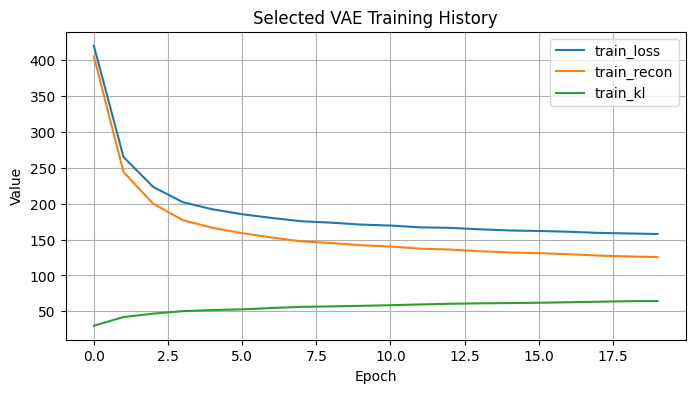

Original images


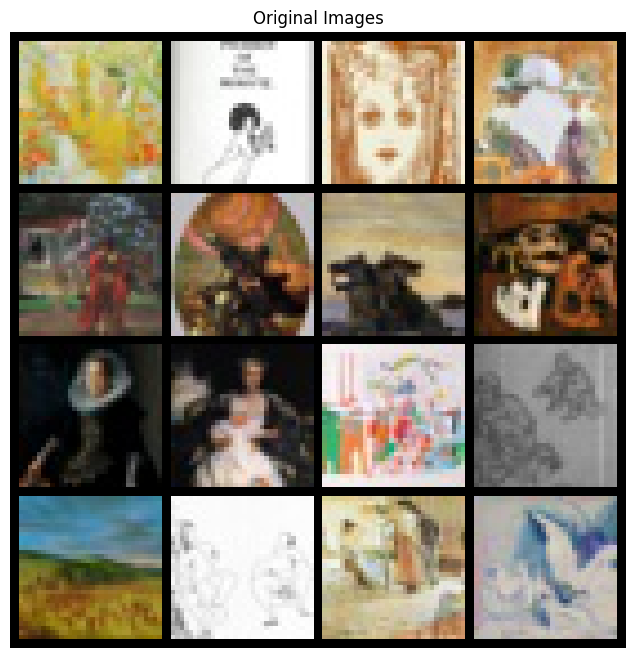

Reconstructed images


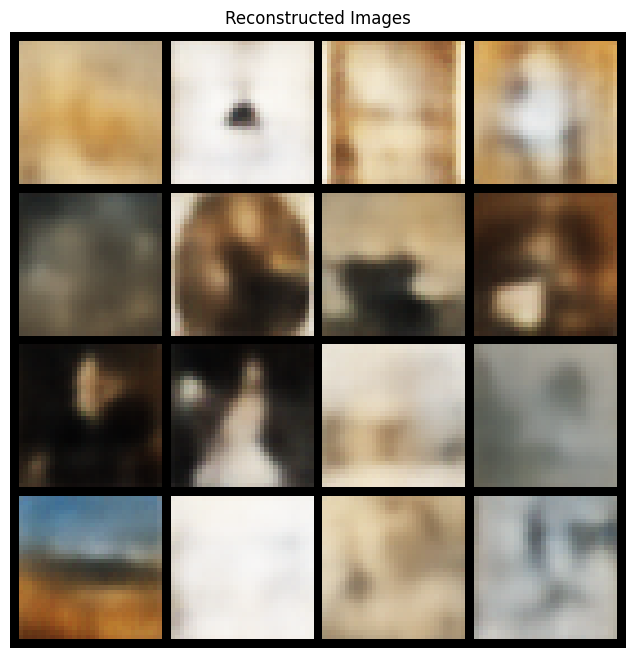

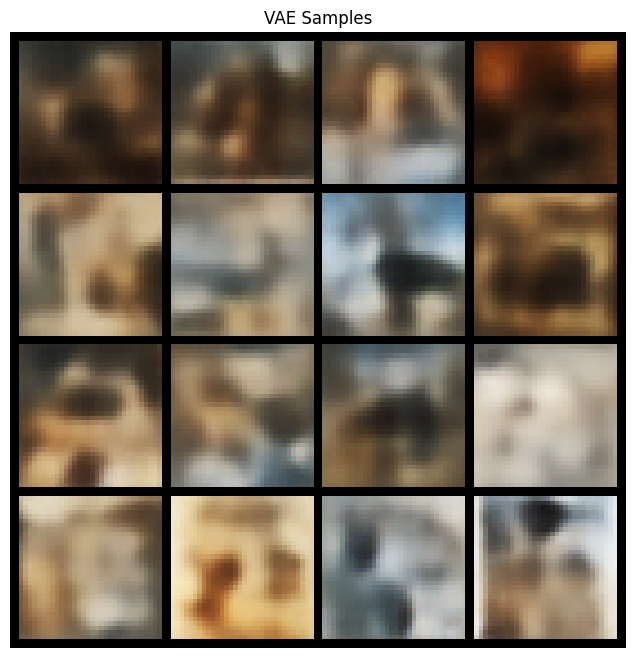

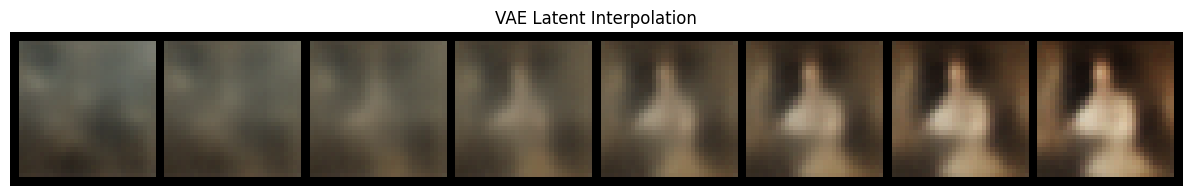

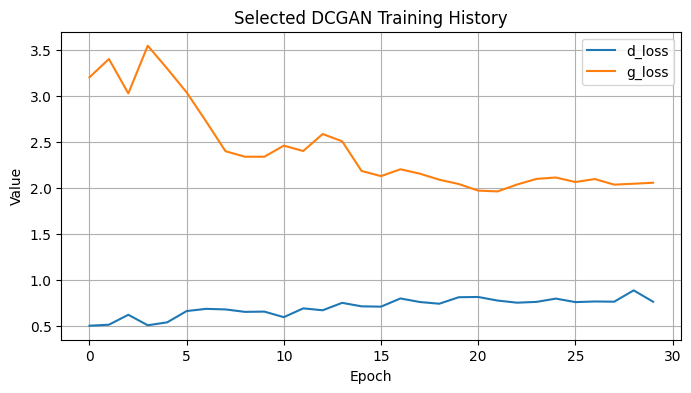

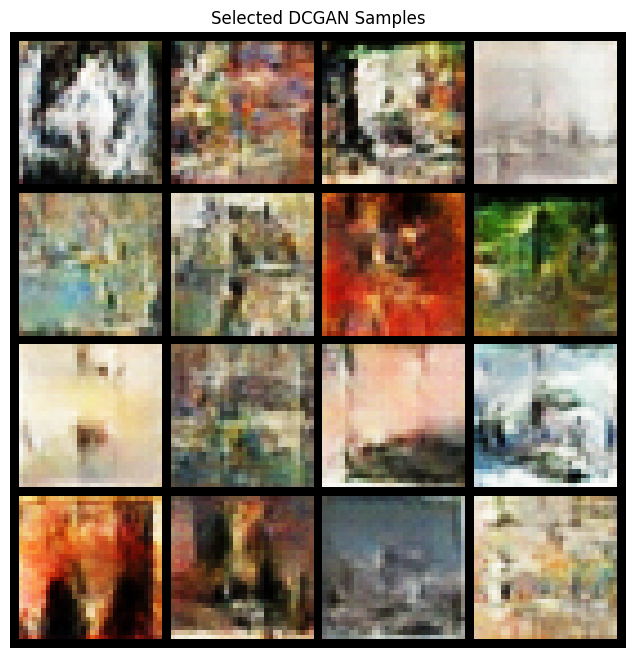

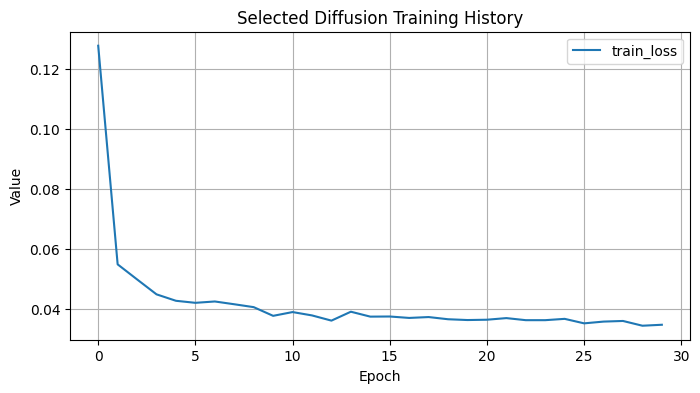

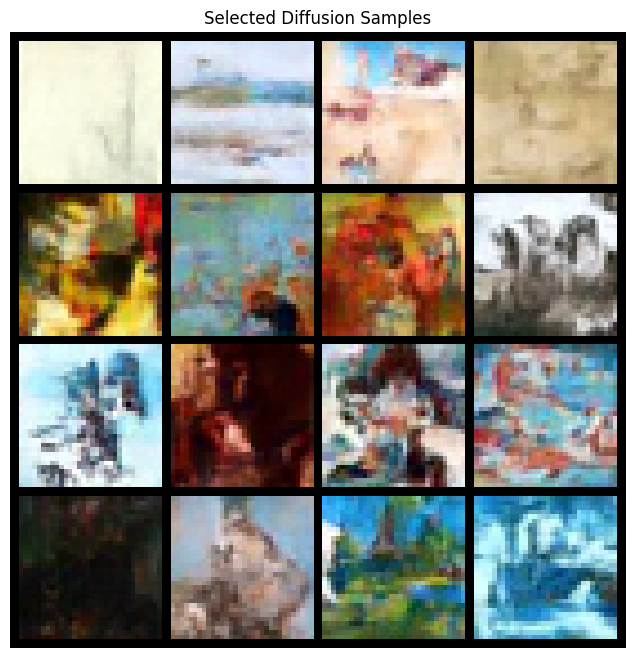

In [40]:
plot_training_history(selected_vae_history, title="Selected VAE Training History")
show_vae_reconstructions(
    selected_vae_model,
    train_loader_from_csv,
    device,
    num_images=16,
)
_ = sample_vae(
    selected_vae_model,
    device,
    num_samples=16,
)
_ = interpolate_vae(
    selected_vae_model,
    train_loader_from_csv,
    device,
    num_steps=8,
)

plot_training_history(selected_dcgan_history, title="Selected DCGAN Training History")
fixed_noise = torch.randn(16, int(selected_dcgan_row["latent_dim"]), 1, 1, device=device)
_ = sample_dcgan(
    selected_dcgan_generator,
    fixed_noise,
    title="Selected DCGAN Samples",
)

plot_training_history(selected_diffusion_history, title="Selected Diffusion Training History")
_ = sample_diffusion(
    selected_diffusion_model,
    selected_diffusion_scheduler,
    device,
    num_samples=16,
    seed=SEED,
    title="Selected Diffusion Samples",
    num_inference_steps=int(selected_diffusion_row["num_train_timesteps"]),
)

## Compare Selected Family Representatives with FID / KID

In [41]:
NUM_EVAL_IMAGES = 5000
EVAL_SEEDS = list(range(10))
KID_SUBSETS = 50
KID_SUBSET_SIZE = 100
EVAL_BATCH_SIZE = 64

subset_family_eval_rows = []

for eval_seed in EVAL_SEEDS:
    print(f"\n=== Evaluation seed: {eval_seed} ===")

    real_imgs = sample_real_images(
        test_hf,
        transform=transform,
        num_images=NUM_EVAL_IMAGES,
        seed=eval_seed,
    )

    fake_vae = generate_vae_images(
        selected_vae_model,
        device=device,
        latent_dim=int(selected_vae_row["latent_dim"]),
        num_images=NUM_EVAL_IMAGES,
        batch_size=EVAL_BATCH_SIZE,
        seed=eval_seed,
    )
    vae_scores = compute_fid_kid(
        real_imgs,
        fake_vae,
        device=device,
        batch_size=EVAL_BATCH_SIZE,
        kid_subsets=KID_SUBSETS,
        kid_subset_size=KID_SUBSET_SIZE,
    )
    subset_family_eval_rows.append({
        "family": "vae",
        "selected_run_idx": int(selected_vae_row["run_idx"]),
        "eval_seed": eval_seed,
        **vae_scores,
    })
    print("VAE:", vae_scores)

    fake_dcgan = generate_dcgan_images(
        selected_dcgan_generator,
        device=device,
        latent_dim=int(selected_dcgan_row["latent_dim"]),
        num_images=NUM_EVAL_IMAGES,
        batch_size=EVAL_BATCH_SIZE,
        seed=eval_seed,
    )
    dcgan_scores = compute_fid_kid(
        real_imgs,
        fake_dcgan,
        device=device,
        batch_size=EVAL_BATCH_SIZE,
        kid_subsets=KID_SUBSETS,
        kid_subset_size=KID_SUBSET_SIZE,
    )
    subset_family_eval_rows.append({
        "family": "dcgan",
        "selected_run_idx": int(selected_dcgan_row["run_idx"]),
        "eval_seed": eval_seed,
        **dcgan_scores,
    })
    print("DCGAN:", dcgan_scores)

    fake_diffusion = generate_diffusion_images(
        selected_diffusion_model,
        selected_diffusion_scheduler,
        device=device,
        num_images=NUM_EVAL_IMAGES,
        batch_size=32,
        seed=eval_seed,
        num_inference_steps=int(selected_diffusion_row["num_train_timesteps"]),
    )
    diffusion_scores = compute_fid_kid(
        real_imgs,
        fake_diffusion,
        device=device,
        batch_size=EVAL_BATCH_SIZE,
        kid_subsets=KID_SUBSETS,
        kid_subset_size=KID_SUBSET_SIZE,
    )
    subset_family_eval_rows.append({
        "family": "diffusion",
        "selected_run_idx": int(selected_diffusion_row["run_idx"]),
        "eval_seed": eval_seed,
        **diffusion_scores,
    })
    print("Diffusion:", diffusion_scores)

subset_family_eval_df = pd.DataFrame(subset_family_eval_rows)
subset_family_eval_df


=== Evaluation seed: 0 ===


c:\git\GAI-Project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


VAE: {'fid': 214.17001342773438, 'kid_mean': 0.2045527547597885, 'kid_std': 0.007833574898540974}
DCGAN: {'fid': 106.56500244140625, 'kid_mean': 0.09074705839157104, 'kid_std': 0.009129432030022144}
Diffusion: {'fid': 67.82588958740234, 'kid_mean': 0.040402818471193314, 'kid_std': 0.007024155929684639}

=== Evaluation seed: 1 ===
VAE: {'fid': 212.4264373779297, 'kid_mean': 0.20130929350852966, 'kid_std': 0.007846476510167122}
DCGAN: {'fid': 105.2113265991211, 'kid_mean': 0.08633899688720703, 'kid_std': 0.008006131276488304}
Diffusion: {'fid': 67.91044616699219, 'kid_mean': 0.03915411978960037, 'kid_std': 0.005668814294040203}

=== Evaluation seed: 2 ===
VAE: {'fid': 212.5715789794922, 'kid_mean': 0.2015121430158615, 'kid_std': 0.007916414178907871}
DCGAN: {'fid': 105.00709533691406, 'kid_mean': 0.08668190985918045, 'kid_std': 0.009466106072068214}
Diffusion: {'fid': 67.13666534423828, 'kid_mean': 0.039146967232227325, 'kid_std': 0.0055345455184578896}

=== Evaluation seed: 3 ===
VAE: {

,family,selected_run_idx,eval_seed,fid,kid_mean,kid_std
0,vae,2,0,214.170013,0.204553,0.007834
1,dcgan,1,0,106.565002,0.090747,0.009129
2,diffusion,2,0,67.825890,0.040403,0.007024
3,vae,2,1,212.426437,0.201309,0.007846
4,dcgan,1,1,105.211327,0.086339,0.008006
5,diffusion,2,1,67.910446,0.039154,0.005669
6,vae,2,2,212.571579,0.201512,0.007916
7,dcgan,1,2,105.007095,0.086682,0.009466
8,diffusion,2,2,67.136665,0.039147,0.005535
9,vae,2,3,212.753708,0.203701,0.008764


## Aggregate Family Comparison

In [42]:
subset_family_summary_df = (
    subset_family_eval_df
    .groupby("family", as_index=False)
    .agg(
        fid_mean=("fid", "mean"),
        fid_std=("fid", "std"),
        kid_mean_mean=("kid_mean", "mean"),
        kid_mean_std=("kid_mean", "std"),
        kid_std_mean=("kid_std", "mean"),
    )
    .sort_values(by=["fid_mean", "kid_mean_mean"], ascending=True)
    .reset_index(drop=True)
)

subset_family_summary_df

,family,fid_mean,fid_std,kid_mean_mean,kid_mean_std,kid_std_mean
0,diffusion,67.465828,0.725421,0.039848,0.001037,0.006628
1,dcgan,105.136359,0.658051,0.087302,0.001682,0.008798
2,vae,212.848987,0.586889,0.202302,0.001227,0.008348


## Select Global Best Family

In [43]:
best_global_family = subset_family_summary_df.iloc[0]["family"]
print("Best global family on subset comparison:", best_global_family)

Best global family on subset comparison: diffusion


## Select Global-Best Configuration

In [44]:
if best_global_family == "vae":
    global_best_config = row_to_vae_config(selected_vae_row)
elif best_global_family == "dcgan":
    global_best_config = row_to_dcgan_config(selected_dcgan_row)
elif best_global_family == "diffusion":
    global_best_config = row_to_diffusion_config(selected_diffusion_row)
else:
    raise ValueError(f"Unknown family: {best_global_family}")

print("Global best family :", best_global_family)
print("Global best config :", global_best_config)

Global best family : diffusion
Global best config : {'learning_rate': 0.0002, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}


## Full-Dataset Retraining Settings

In [45]:
FULL_NUM_EPOCHS = 30
FULL_TRAIN_SEEDS = list(range(10))
FINAL_NUM_EVAL_IMAGES = 5000
FINAL_EVAL_BATCH_SIZE = 64
FINAL_KID_SUBSETS = 50
FINAL_KID_SUBSET_SIZE = 100

## Train Selected Family on Full Dataset

In [46]:
def train_selected_family_on_full_dataset(family, config, train_loader, device, num_epochs=10, seed=42):
    if family == "vae":
        model, history, result = run_vae_experiment(
            config=config,
            train_loader=train_loader,
            device=device,
            num_epochs=num_epochs,
            seed=seed,
        )
        return {
            "family": family,
            "model": model,
            "history": history,
            "train_result": result,
        }

    if family == "dcgan":
        generator, discriminator, history, result = run_dcgan_experiment(
            config=config,
            train_loader=train_loader,
            device=device,
            num_epochs=num_epochs,
            seed=seed,
        )
        return {
            "family": family,
            "generator": generator,
            "discriminator": discriminator,
            "history": history,
            "train_result": result,
        }

    if family == "diffusion":
        model, scheduler, history, result = run_diffusion_experiment(
            config=config,
            train_loader=train_loader,
            device=device,
            num_epochs=num_epochs,
            seed=seed,
        )
        return {
            "family": family,
            "model": model,
            "scheduler": scheduler,
            "history": history,
            "train_result": result,
        }

    raise ValueError(f"Unknown family: {family}")

## Evaluate Trained Family Model

In [47]:
def evaluate_trained_family_model(trained_spec, hf_test_split, transform, device, eval_seed=42, num_eval_images=5000):
    real_imgs = sample_real_images(
        hf_test_split,
        transform=transform,
        num_images=num_eval_images,
        seed=eval_seed,
    )

    family = trained_spec["family"]

    if family == "vae":
        latent_dim = int(trained_spec["train_result"]["latent_dim"])
        fake_imgs = generate_vae_images(
            trained_spec["model"],
            device=device,
            latent_dim=latent_dim,
            num_images=num_eval_images,
            batch_size=FINAL_EVAL_BATCH_SIZE,
            seed=eval_seed,
        )

    elif family == "dcgan":
        latent_dim = int(trained_spec["train_result"]["latent_dim"])
        fake_imgs = generate_dcgan_images(
            trained_spec["generator"],
            device=device,
            latent_dim=latent_dim,
            num_images=num_eval_images,
            batch_size=FINAL_EVAL_BATCH_SIZE,
            seed=eval_seed,
        )

    elif family == "diffusion":
        num_steps = int(trained_spec["train_result"]["num_train_timesteps"])
        fake_imgs = generate_diffusion_images(
            trained_spec["model"],
            trained_spec["scheduler"],
            device=device,
            num_images=num_eval_images,
            batch_size=32,
            seed=eval_seed,
            num_inference_steps=num_steps,
        )

    else:
        raise ValueError(f"Unknown family: {family}")

    scores = compute_fid_kid(
        real_imgs,
        fake_imgs,
        device=device,
        batch_size=FINAL_EVAL_BATCH_SIZE,
        kid_subsets=FINAL_KID_SUBSETS,
        kid_subset_size=FINAL_KID_SUBSET_SIZE,
    )
    return scores

## Final Full-Dataset Protocol

In [48]:
final_runs = []

for seed in FULL_TRAIN_SEEDS:
    print("\n" + "=" * 100)
    print(f"FULL TRAIN + FINAL EVAL | family={best_global_family} | seed={seed}")

    trained_spec = train_selected_family_on_full_dataset(
        family=best_global_family,
        config=global_best_config,
        train_loader=train_loader,
        device=device,
        num_epochs=FULL_NUM_EPOCHS,
        seed=seed,
    )

    final_scores = evaluate_trained_family_model(
        trained_spec=trained_spec,
        hf_test_split=test_hf,
        transform=transform,
        device=device,
        eval_seed=seed,
        num_eval_images=FINAL_NUM_EVAL_IMAGES,
    )

    row = {
        "family": best_global_family,
        "seed": seed,
        **trained_spec["train_result"],
        **final_scores,
    }
    final_runs.append(row)

    print("Final scores:", final_scores)

final_results_df = pd.DataFrame(final_runs)
final_results_df


FULL TRAIN + FINAL EVAL | family=diffusion | seed=0
----------------------------------------------------------------------
Training Diffusion | learning_rate=0.0002 | num_train_timesteps=1000 | block_out_channels=(64, 128, 128)
Trainable parameters: 6,472,195


Training:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [1/30] loss=0.0637


Training:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [2/30] loss=0.0405


...

Training:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [29/30] loss=0.0326


Training:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [30/30] loss=0.0331
Final scores: {'fid': 62.68971633911133, 'kid_mean': 0.04975685104727745, 'kid_std': 0.00651280814781785}


,family,seed,learning_rate,num_train_timesteps,block_out_channels,num_epochs,final_train_loss,fid,kid_mean,kid_std
0,diffusion,0,0.0002,1000,"(64, 128, 128)",30,0.033462,63.390812,0.045635,0.006866
1,diffusion,1,0.0002,1000,"(64, 128, 128)",30,0.032659,67.025558,0.055686,0.007775
2,diffusion,2,0.0002,1000,"(64, 128, 128)",30,0.033135,41.303825,0.022261,0.003957
3,diffusion,3,0.0002,1000,"(64, 128, 128)",30,0.033076,67.135124,0.050302,0.007603
4,diffusion,4,0.0002,1000,"(64, 128, 128)",30,0.033278,46.627926,0.028135,0.004896
5,diffusion,5,0.0002,1000,"(64, 128, 128)",30,0.033452,52.718449,0.036857,0.005311
6,diffusion,6,0.0002,1000,"(64, 128, 128)",30,0.032956,58.489773,0.038660,0.006752
7,diffusion,7,0.0002,1000,"(64, 128, 128)",30,0.033162,74.088409,0.055765,0.007060
8,diffusion,8,0.0002,1000,"(64, 128, 128)",30,0.033530,47.841312,0.029470,0.005311
9,diffusion,9,0.0002,1000,"(64, 128, 128)",30,0.033073,62.689716,0.049757,0.006513


## Final Report-Ready Summary

In [49]:
final_summary_df = (
    final_results_df
    .agg({
        "fid": ["mean", "std"],
        "kid_mean": ["mean", "std"],
    })
)

final_summary_df

,fid,kid_mean
mean,58.131091,0.041253
std,10.614720,0.011972


## Save Final Summary

In [50]:
final_results_df.to_csv("final_results_per_seed.csv", index=False)
final_summary_df.to_csv("final_results_summary.csv")

print("Saved:")
print(" - final_results_per_seed.csv")
print(" - final_results_summary.csv")

Saved:
 - final_results_per_seed.csv
 - final_results_summary.csv
